In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_pacf

In [18]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

In [19]:
data['time'] = pd.to_datetime(data['time'])

In [20]:
data = data.sort_values('time')
data.set_index('time', inplace=True)
pm25 = data['pm2_5']

<Figure size 1200x600 with 0 Axes>

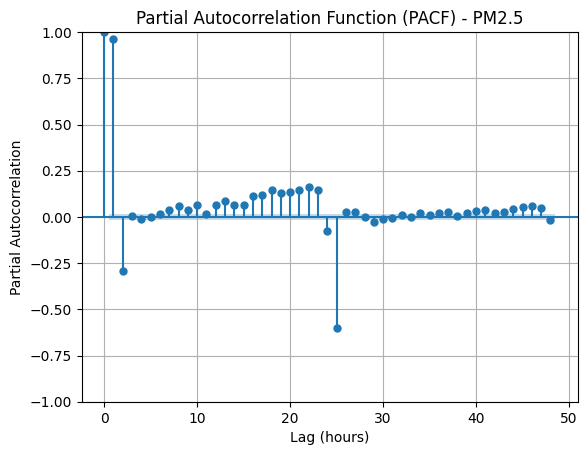

In [21]:
plt.figure(figsize=(12, 6))
plot_pacf(
    pm25,
    lags=48,              # 48 hourly lags = 2 days
    method='ywm'
)
plt.title('Partial Autocorrelation Function (PACF) - PM2.5')
plt.xlabel('Lag (hours)')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [22]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

# Convert timestamp column
data['time'] = pd.to_datetime(data['time'], dayfirst=False)

# Sort by time just in case
data = data.sort_values('time').reset_index(drop=True)
lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]  # 168 = 7 days

In [23]:
for lag in lags:
    data[f'pm2_5_lag_{lag}'] = data['pm2_5'].shift(lag)

In [24]:
correlations = {}

for lag in lags:
    corr = data['pm2_5'].corr(data[f'pm2_5_lag_{lag}'])
    correlations[lag] = corr


In [25]:
corr_df = pd.DataFrame({
    'Lag (hours)': correlations.keys(),
    'Correlation': correlations.values()
})

corr_df = corr_df.sort_values('Lag (hours)')

print("\nLag Correlation Analysis")
print(corr_df)


Lag Correlation Analysis
   Lag (hours)  Correlation
0            1     0.965610
1            2     0.912207
2            3     0.855741
3            6     0.698393
4           12     0.549153
5           24     0.855907
6           48     0.768230
7           72     0.711658
8          168     0.611813


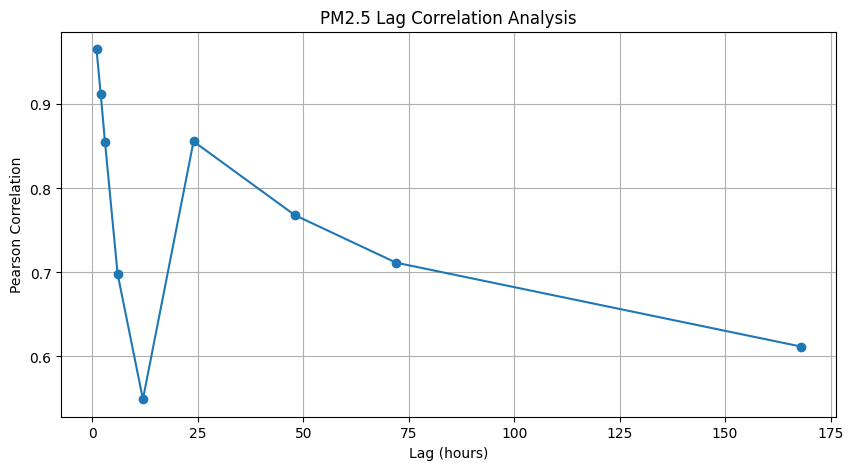

In [26]:
plt.figure(figsize=(10,5))
plt.plot(corr_df['Lag (hours)'],
         corr_df['Correlation'],
         marker='o')
plt.xlabel('Lag (hours)')
plt.ylabel('Pearson Correlation')
plt.title('PM2.5 Lag Correlation Analysis')
plt.grid(True)
plt.show()

In [27]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

# Convert time column to datetime
data['time'] = pd.to_datetime(data['time'])
data = data.sort_values('time').set_index('time')

In [28]:
target = 'pm2_5'
weather_vars = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'wind_direction_10m',
    'surface_pressure'
]
MAX_LAG = 48

In [29]:
def cross_correlation(series_x, series_y, max_lag):
    """
    Computes Pearson correlation for lags from -max_lag to +max_lag.

    Positive lag:
        Weather variable leads PM2.5
        (weather at t affects PM2.5 at t+lag)

    Negative lag:
        PM2.5 leads weather variable
    """
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []

    for lag in lags:
        if lag < 0:
            corr = series_x[:lag].corr(series_y[-lag:])
        elif lag > 0:
            corr = series_x[lag:].corr(series_y[:-lag])
        else:
            corr = series_x.corr(series_y)

        correlations.append(corr)

    return lags, correlations


temperature_2m
Strongest correlation = -0.523
Best lag = 0 hours


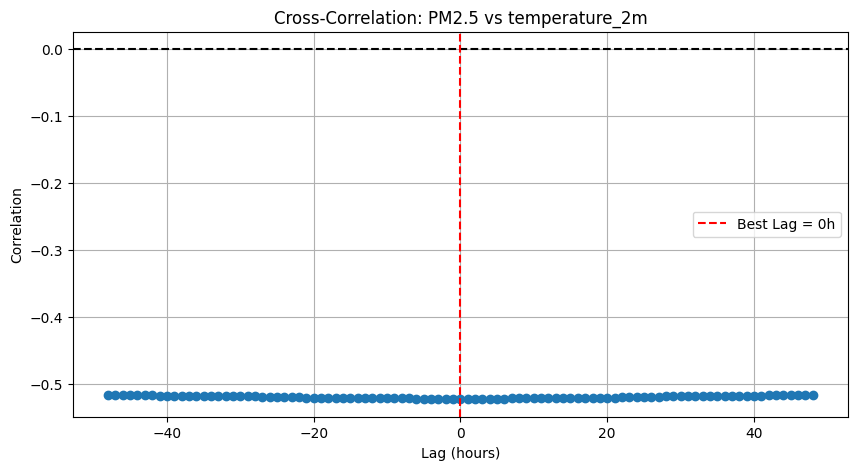


relative_humidity_2m
Strongest correlation = 0.046
Best lag = -15 hours


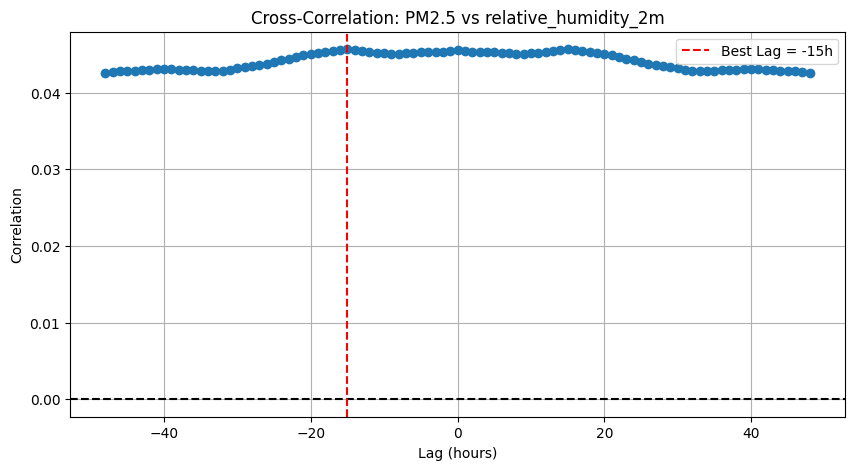


wind_speed_10m
Strongest correlation = -0.111
Best lag = 0 hours


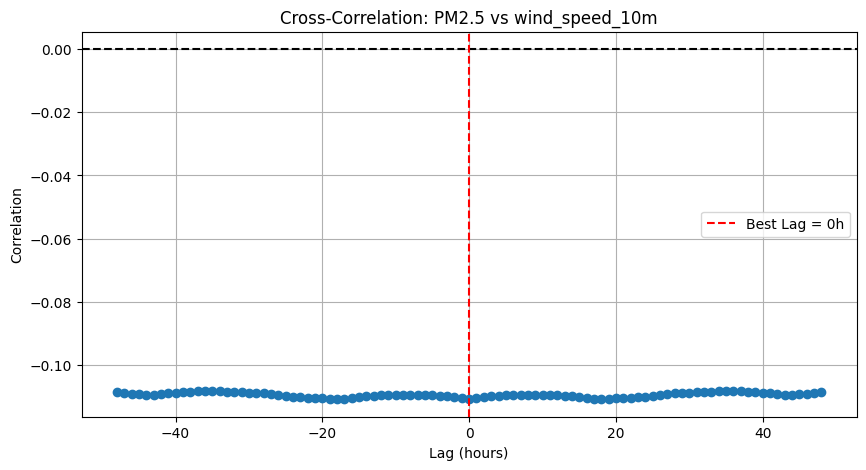


wind_direction_10m
Strongest correlation = -0.109
Best lag = 0 hours


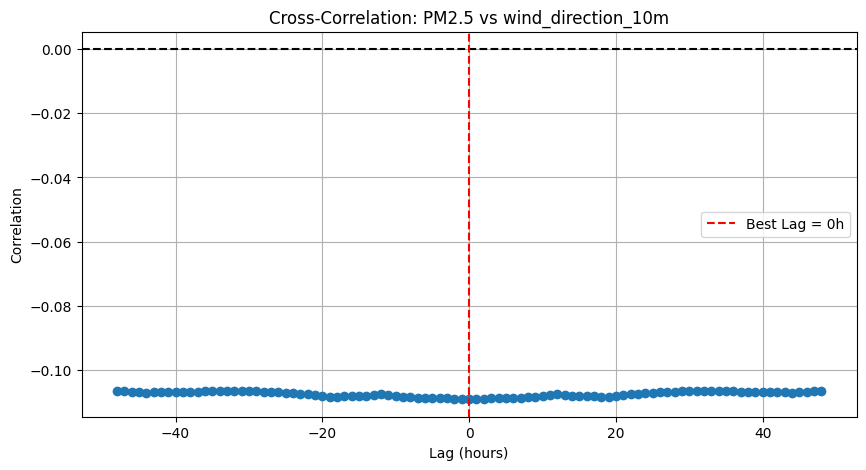


surface_pressure
Strongest correlation = 0.176
Best lag = 0 hours


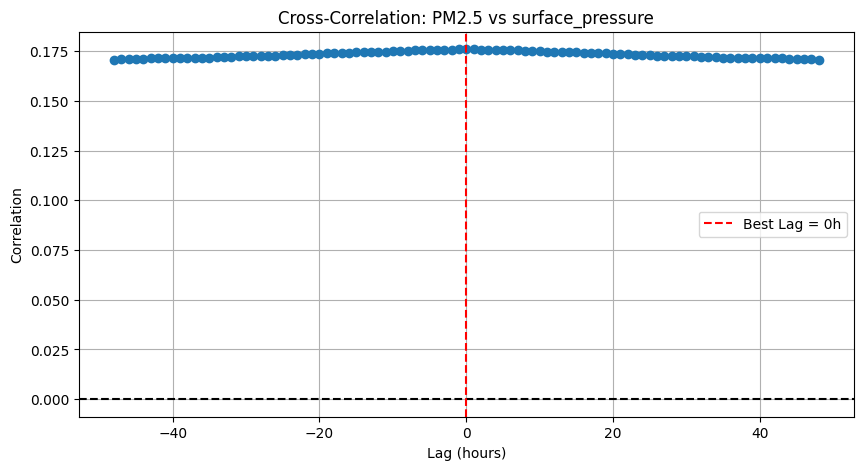

In [30]:
# ==========================
# Cross-Correlation Plots
# ==========================
for var in weather_vars:

    lags, corrs = cross_correlation(
        data[target],
        data[var],
        MAX_LAG
    )

    # Best lag
    best_idx = np.nanargmax(np.abs(corrs))
    best_lag = lags[best_idx]
    best_corr = corrs[best_idx]

    print(f"\n{var}")
    print(f"Strongest correlation = {best_corr:.3f}")
    print(f"Best lag = {best_lag} hours")

    plt.figure(figsize=(10, 5))
    plt.plot(lags, corrs, marker='o')
    plt.axhline(0, color='black', linestyle='--')
    plt.axvline(best_lag, color='red', linestyle='--',
                label=f'Best Lag = {best_lag}h')
    plt.title(f'Cross-Correlation: PM2.5 vs {var}')
    plt.xlabel('Lag (hours)')
    plt.ylabel('Correlation')
    plt.legend()
    plt.grid(True)
    plt.show()

In [31]:
results = []

for var in weather_vars:
    lags, corrs = cross_correlation(
        data[target],
        data[var],
        MAX_LAG
    )

    best_idx = np.nanargmax(np.abs(corrs))

    results.append({
        'Variable': var,
        'Best_Lag_Hours': lags[best_idx],
        'Correlation': corrs[best_idx]
    })

summary = pd.DataFrame(results)
summary = summary.sort_values(
    by='Correlation',
    key=lambda x: np.abs(x),
    ascending=False
)

print("\nCross-Correlation Summary")
print(summary)


Cross-Correlation Summary
               Variable  Best_Lag_Hours  Correlation
0        temperature_2m               0    -0.522716
4      surface_pressure               0     0.175934
2        wind_speed_10m               0    -0.110932
3    wind_direction_10m               0    -0.109160
1  relative_humidity_2m             -15     0.045658
